In [2]:
import math
import time
import numpy as np
import torch
from torch import nn
from torchvision import transforms
import matplotlib.pyplot as plt
import random

## 3.2.1 Initialize Database

In [3]:
def synthetic_data(w, b, num_examples):
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

In [4]:
true_w = torch.tensor([2.0, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

<Figure size 350x250 with 0 Axes>

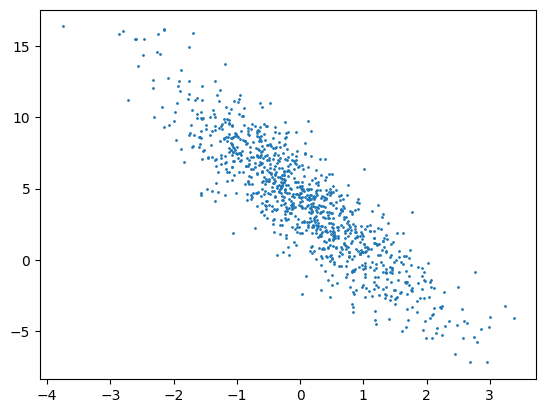

<Figure size 350x250 with 0 Axes>

In [5]:
plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1)
plt.figure(figsize = (3.5, 2.5))

## 3.2.2 Read Database

In [6]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)] # 保证样本不被遗漏且不越界
        )
        yield features[batch_indices], labels[batch_indices] 

In [7]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-0.5734, -1.6787],
        [ 0.4402,  0.9940],
        [-0.0574,  0.1914],
        [ 1.0570, -0.6846],
        [-0.0248, -0.2434],
        [ 0.1626,  1.0127],
        [ 2.3363, -0.2442],
        [ 0.1408, -0.4895],
        [-0.1759,  0.2410],
        [-0.1048, -0.2325]]) 
 tensor([[8.7738],
        [1.6912],
        [3.4366],
        [8.6537],
        [4.9711],
        [1.0775],
        [9.7004],
        [6.1372],
        [3.0274],
        [4.7800]])


## 3.2.3 Initialize Parameters

In [8]:
w = torch.normal(0, 0.01, size = (2, 1), requires_grad = True)
b = torch.zeros(1, requires_grad = True)

## 3.2.4-6 Define the Model & Loss & Optimization

In [9]:
def linreg(X, w, b):
    return torch.matmul(X, w) + b

In [10]:
def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [11]:
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

## 3.2.7 Train

In [12]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

In [13]:
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.038609
epoch 2, loss 0.000144
epoch 3, loss 0.000051


In [14]:
print(f'w loss: {true_w - w.reshape(true_w.shape)}')
print(f'b loss: {true_b - b}')

w loss: tensor([ 0.0010, -0.0001], grad_fn=<SubBackward0>)
b loss: tensor([0.0009], grad_fn=<RsubBackward1>)


## 3.3 Brief Realization of Linear Regression

In [15]:
from torch.utils import data

In [16]:
true_w = torch.tensor([2.0, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [17]:
def load_array(data_arrays, batch_size, is_train = True):
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle = is_train)

In [18]:
batch_size = 10
data_iter = load_array((features, labels), batch_size)

In [19]:
next(iter(data_iter))

[tensor([[ 1.4135, -0.1009],
         [-0.5222, -0.8927],
         [-1.6234,  0.8821],
         [-0.6267,  0.1436],
         [-0.7116, -0.6211],
         [ 1.9269,  0.8187],
         [ 0.7629, -1.3740],
         [ 0.3132, -0.0117],
         [-0.4893, -0.0301],
         [ 0.1886, -0.8963]]),
 tensor([[ 7.3702],
         [ 6.1862],
         [-2.0452],
         [ 2.4573],
         [ 4.8874],
         [ 5.2608],
         [10.3959],
         [ 4.8864],
         [ 3.3246],
         [ 7.6129]])]

In [20]:
from torch import nn

net = nn.Sequential(nn.Linear(2, 1))

In [21]:
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

tensor([0.])

In [22]:
# loss = nn.MSELoss()
loss = nn.SmoothL1Loss(beta = 1.0) # Huber

In [23]:
trainer = torch.optim.SGD(net.parameters(), lr = 0.03)

In [25]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        # print(w.grad)
        trainer.step()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000056
epoch 2, loss 0.000053
epoch 3, loss 0.000053
